# MRI GRAPPA Reconstruction

This notebook demonstrates **GRAPPA** (GeneRalized Autocalibrating Partially Parallel Acquisitions) for multi-coil MRI reconstruction. Unlike optimization-based methods (TV, PnP), GRAPPA directly interpolates missing k-space samples using linear kernels calibrated from a fully-sampled auto-calibration signal (ACS) region.

The notebook loads precomputed reference outputs and runs in seconds.

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.getcwd(), ".."))
from src.preprocessing import load_observation, load_ground_truth, get_full_kspace, undersample_kspace
from src.physics_model import fully_sampled_recon, zero_filled_recon
from src.visualization import compute_metrics, print_metrics

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## 1. Load Data

In [2]:
DATA_DIR = os.path.join("..", "data")
REF_DIR = os.path.join("..", "evaluation", "reference_outputs")

obs = load_observation(DATA_DIR)
kf = get_full_kspace(obs)
kus, calib, mask = undersample_kspace(kf, R=2, acs_width=20)

recon_grappa = np.load(os.path.join(REF_DIR, "grappa_reconstruction.npz"))["reconstruction"][0]
recon_zf = np.load(os.path.join(REF_DIR, "zerofill.npz"))["reconstruction"][0]
ref_img = np.load(os.path.join(REF_DIR, "ground_truth.npy"))

print(f"K-space: {kf.shape} ({kf.shape[-1]} coils)")
print(f"Sampling: {mask.sum()/len(mask)*100:.1f}% of phase-encode lines")

K-space: (128, 128, 8) (8 coils)
Sampling: 57.8% of phase-encode lines


## 2. K-Space Undersampling

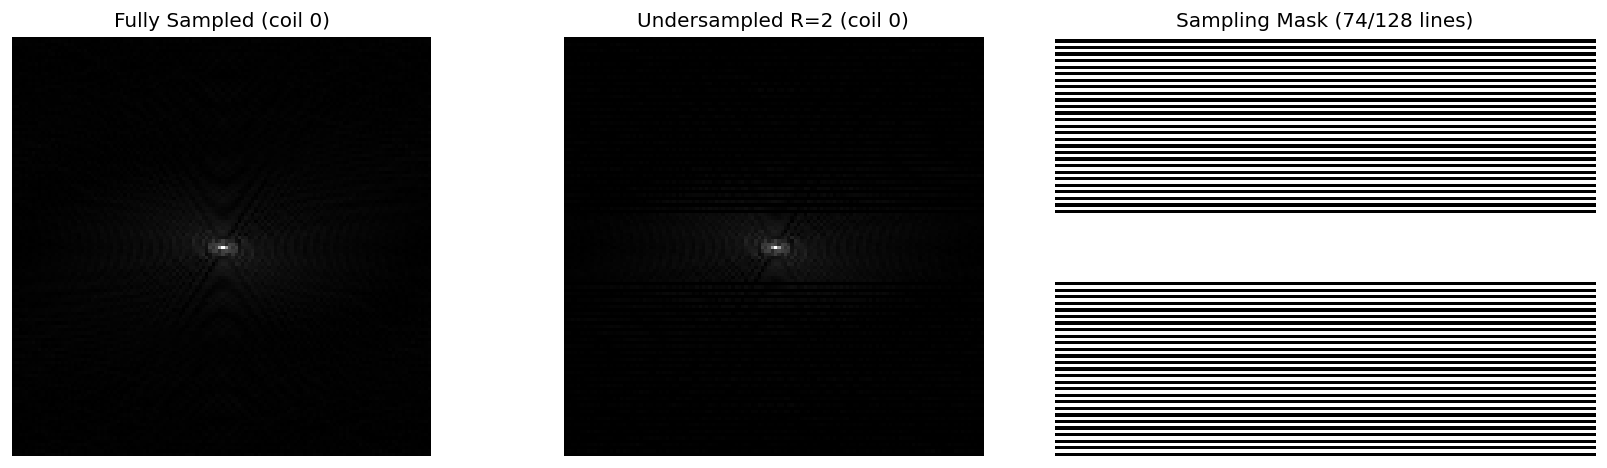

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(np.log1p(np.abs(kf[..., 0])), cmap="gray")
axes[0].set_title("Fully Sampled (coil 0)")
axes[1].imshow(np.log1p(np.abs(kus[..., 0])), cmap="gray")
axes[1].set_title("Undersampled R=2 (coil 0)")
axes[2].imshow(mask[:, None] * np.ones((1, 128)), cmap="gray", aspect="auto")
axes[2].set_title(f"Sampling Mask ({mask.sum()}/{len(mask)} lines)")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Reconstruction Comparison

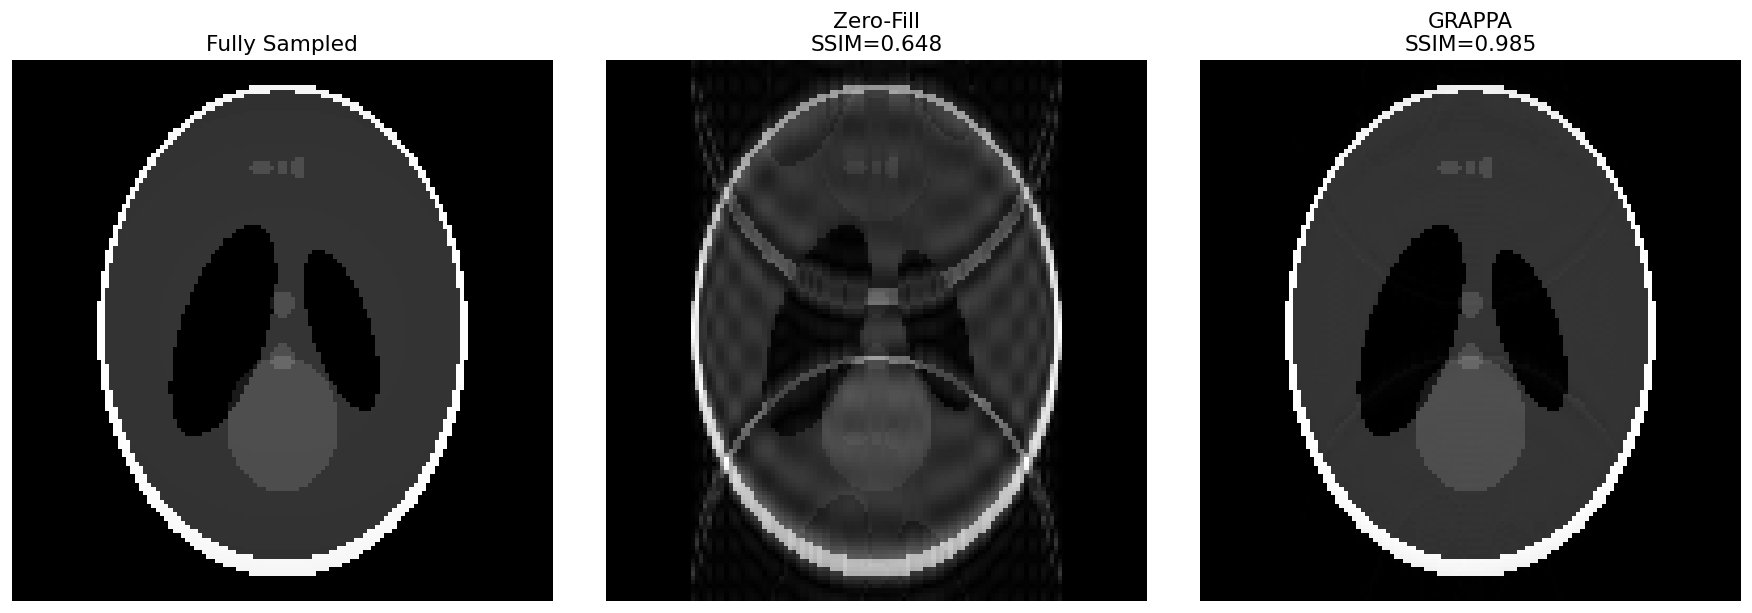

In [4]:
m_g = compute_metrics(recon_grappa.astype(np.float64), ref_img.astype(np.float64))
m_zf = compute_metrics(recon_zf.astype(np.float64), ref_img.astype(np.float64))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title in zip(axes,
    [ref_img, recon_zf, recon_grappa],
    ["Fully Sampled", f"Zero-Fill\nSSIM={m_zf['ssim']:.3f}", f"GRAPPA\nSSIM={m_g['ssim']:.3f}"]):
    ax.imshow(img, cmap="gray")
    ax.set_title(title, fontsize=13)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Error Maps

/var/folders/g6/91c6hhdn27b9rch26vg33z240000gp/T/ipykernel_43437/1474756732.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


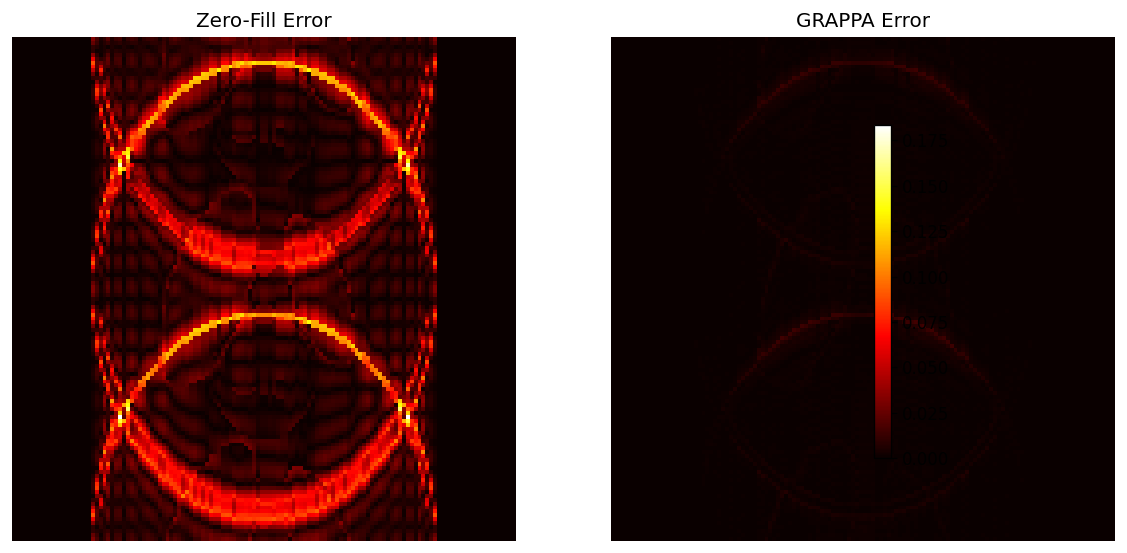

In [5]:
err_zf = np.abs(recon_zf.astype(np.float64) - ref_img.astype(np.float64))
err_g = np.abs(recon_grappa.astype(np.float64) - ref_img.astype(np.float64))
vmax = max(err_zf.max(), err_g.max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].imshow(err_zf, cmap="hot", vmin=0, vmax=vmax)
axes[0].set_title("Zero-Fill Error")
axes[0].axis("off")
im = axes[1].imshow(err_g, cmap="hot", vmin=0, vmax=vmax)
axes[1].set_title("GRAPPA Error")
axes[1].axis("off")
plt.colorbar(im, ax=axes, shrink=0.8)
plt.tight_layout()
plt.show()

## 5. Quantitative Metrics

In [6]:
print("=" * 50)
print("GRAPPA vs Fully Sampled:")
print_metrics(m_g)
print("\nZero-Fill vs Fully Sampled:")
print_metrics(m_zf)
print("=" * 50)

GRAPPA vs Fully Sampled:
  SSIM:  0.9852
  NCC:   0.999862
  NRMSE: 0.004071

Zero-Fill vs Fully Sampled:
  SSIM:  0.6478
  NCC:   0.950926
  NRMSE: 0.074920


## 6. Run from Scratch (Optional)

In [7]:
# from src.solvers import grappa_image_recon
# recon_new = grappa_image_recon(kus, calib, kernel_size=(5, 5), lamda=0.01)
# m = compute_metrics(recon_new, ref_img.astype(np.float64))
# print(f"SSIM={m['ssim']:.4f}, NCC={m['ncc']:.6f}, NRMSE={m['nrmse']:.6f}")

## Conclusion

GRAPPA reconstructs a high-quality image (SSIM=0.985) from 2x-accelerated multi-coil k-space by calibrating linear interpolation kernels from a 20-line ACS region. Unlike optimization-based methods, GRAPPA is:
- **Non-iterative**: no convergence loop, no regularization parameter tuning
- **K-space domain**: operates directly on Fourier data, not image space
- **Calibration-based**: exploits inter-coil correlations learned from the ACS region